<a href="https://colab.research.google.com/github/Harikrishna011/SMAnomlyDect/blob/main/StockAnomly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preprocesisng of data

In [3]:
import pandas as pd
import yfinance as yf
from datetime import date, timedelta

end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")
tickers = ['AAPL', 'MSFT', 'NFLX', 'GOOG', 'TSLA']
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

data = data.reset_index()

data.columns = ['Date'] + [f'{attr}_{ticker}' for attr, ticker in data.columns[1:]]
data_melted = data.melt(id_vars=['Date'], var_name='Attribute_Ticker', value_name='value')

data_melted[['Attribute', 'Ticker']] = data_melted['Attribute_Ticker'].str.split('_', expand=True)


data_pivoted = data_melted.pivot_table(index=['Date', 'Ticker'], columns='Attribute', values='value', aggfunc='first')

stock_data = data_pivoted.reset_index()

print(stock_data.head())


YF.download() has changed argument auto_adjust default to True
Attribute       Date Ticker       Close        High         Low        Open  \
0         2024-05-03   AAPL  182.518173  186.121155  181.801556  185.772794   
1         2024-05-03   GOOG  168.193375  169.049321  164.202268  168.740770   
2         2024-05-03   MSFT  403.578796  404.065074  398.815147  399.231978   
3         2024-05-03   NFLX  579.340027  580.260010  565.159973  566.000000   
4         2024-05-03   TSLA  181.190002  184.779999  178.419998  182.100006   

Attribute       Volume  
0          163224100.0  
1           22767100.0  
2           17446700.0  
3            3307500.0  
4           75491500.0  


In [4]:
data_melted.head()

,Date,Attribute_Ticker,value,Attribute,Ticker
0,2024-05-03,Close_AAPL,182.518173,Close,AAPL
1,2024-05-06,Close_AAPL,180.856033,Close,AAPL
2,2024-05-07,Close_AAPL,181.542786,Close,AAPL
3,2024-05-08,Close_AAPL,181.881195,Close,AAPL
4,2024-05-09,Close_AAPL,183.702606,Close,AAPL


In [5]:
data_pivoted.head()

Attribute               Close        High         Low        Open       Volume
Date       Ticker                                                             
2024-05-03 AAPL    182.518173  186.121155  181.801556  185.772794  163224100.0
           GOOG    168.193375  169.049321  164.202268  168.740770   22767100.0
           MSFT    403.578796  404.065074  398.815147  399.231978   17446700.0
           NFLX    579.340027  580.260010  565.159973  566.000000    3307500.0
           TSLA    181.190002  184.779999  178.419998  182.100006   75491500.0

In [6]:
stock_data['Date']=pd.to_datetime(stock_data['Date'])
stock_data.set_index(['Date'],inplace=True)
stock_data.head()

Attribute,Ticker,Close,High,Low,Open,Volume
Date,,,,,,
2024-05-03,AAPL,182.518173,186.121155,181.801556,185.772794,163224100.0
2024-05-03,GOOG,168.193375,169.049321,164.202268,168.740770,22767100.0
2024-05-03,MSFT,403.578796,404.065074,398.815147,399.231978,17446700.0
2024-05-03,NFLX,579.340027,580.260010,565.159973,566.000000,3307500.0
2024-05-03,TSLA,181.190002,184.779999,178.419998,182.100006,75491500.0


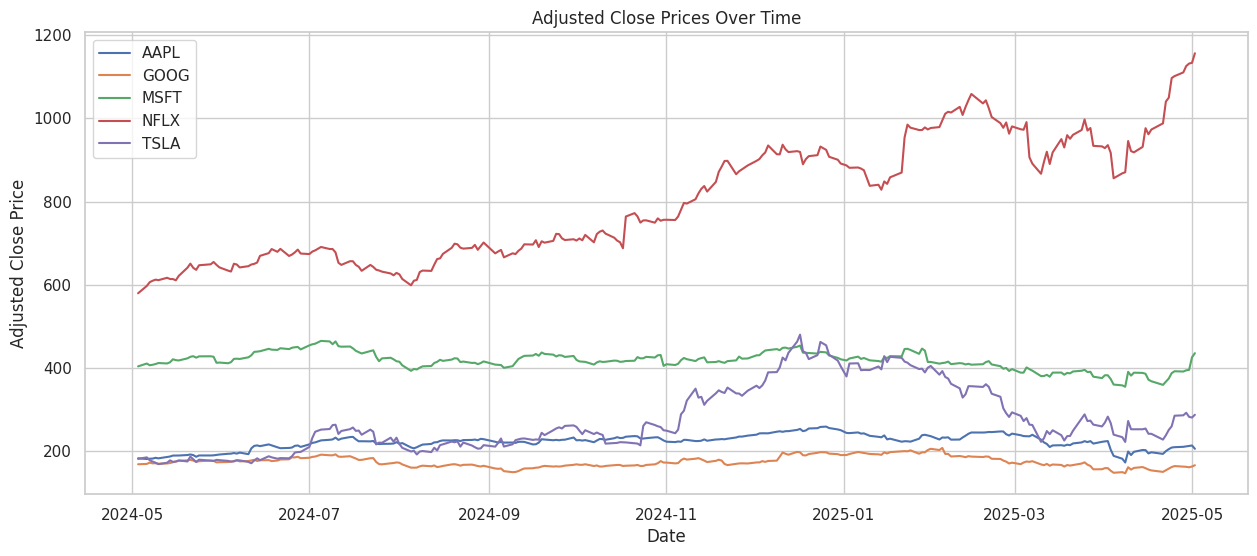

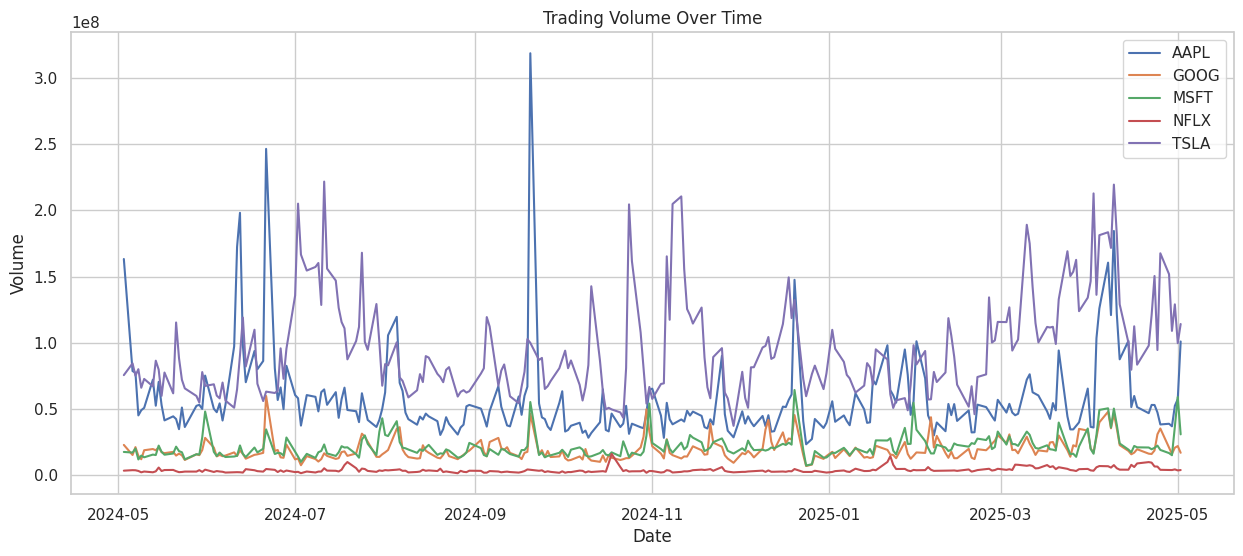

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


plt.figure(figsize=(15, 6))
for ticker in stock_data['Ticker'].unique():
    subset = stock_data[stock_data['Ticker'] == ticker]
    plt.plot(subset.index, subset['Close'], label=ticker)

plt.title('Adjusted Close Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.show()


plt.figure(figsize=(15, 6))
for ticker in stock_data['Ticker'].unique():
    subset = stock_data[stock_data['Ticker'] == ticker]
    plt.plot(subset.index, subset['Volume'], label=ticker)

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

In [8]:
from scipy.stats import zscore

def detect_anomalies(df, column):
    df_copy = df.copy()
    df_copy['Z-score'] = zscore(df_copy[column])
    anomalies = df_copy[abs(df_copy['Z-score']) > 2]
    return anomalies

anomalies_adj_close = pd.DataFrame()
anomalies_volume = pd.DataFrame()

for ticker in stock_data['Ticker'].unique():
    data_ticker = stock_data[stock_data['Ticker'] == ticker]

    adj_close_anomalies = detect_anomalies(data_ticker, 'Close')
    volume_anomalies = detect_anomalies(data_ticker, 'Volume')
    anomalies_adj_close = pd.concat([anomalies_adj_close, adj_close_anomalies])
    anomalies_volume = pd.concat([anomalies_volume, volume_anomalies])

print(anomalies_adj_close.head())

Attribute  Ticker       Close        High         Low        Open  \
Date                                                                
2024-05-03   AAPL  182.518173  186.121155  181.801556  185.772794   
2024-05-06   AAPL  180.856033  183.334321  179.572087  181.493025   
2024-05-07   AAPL  181.542786  184.031037  180.467875  182.587854   
2024-05-08   AAPL  181.881195  182.209646  180.597249  181.990679   
2024-05-09   AAPL  183.702606  183.792180  181.254160  181.702043   

Attribute        Volume   Z-score  
Date                               
2024-05-03  163224100.0 -2.263376  
2024-05-06   78569700.0 -2.358675  
2024-05-07   77305800.0 -2.319300  
2024-05-08   45057100.0 -2.299897  
2024-05-09   48983000.0 -2.195467  


In [9]:
print(anomalies_volume.head())

Attribute  Ticker       Close        High         Low        Open  \
Date                                                                
2024-05-03   AAPL  182.518173  186.121155  181.801556  185.772794   
2024-06-11   AAPL  206.456100  206.466077  192.981400  193.001322   
2024-06-12   AAPL  212.356308  219.462415  206.206962  206.675389   
2024-06-21   AAPL  206.794998  211.180254  206.416266  209.685278   
2024-09-20   AAPL  227.698853  232.578113  227.120124  229.464970   

Attribute        Volume   Z-score  
Date                               
2024-05-03  163224100.0  3.219126  
2024-06-11  172373300.0  3.495526  
2024-06-12  198134300.0  4.273773  
2024-06-21  246421400.0  5.732539  
2024-09-20  318679900.0  7.915488  


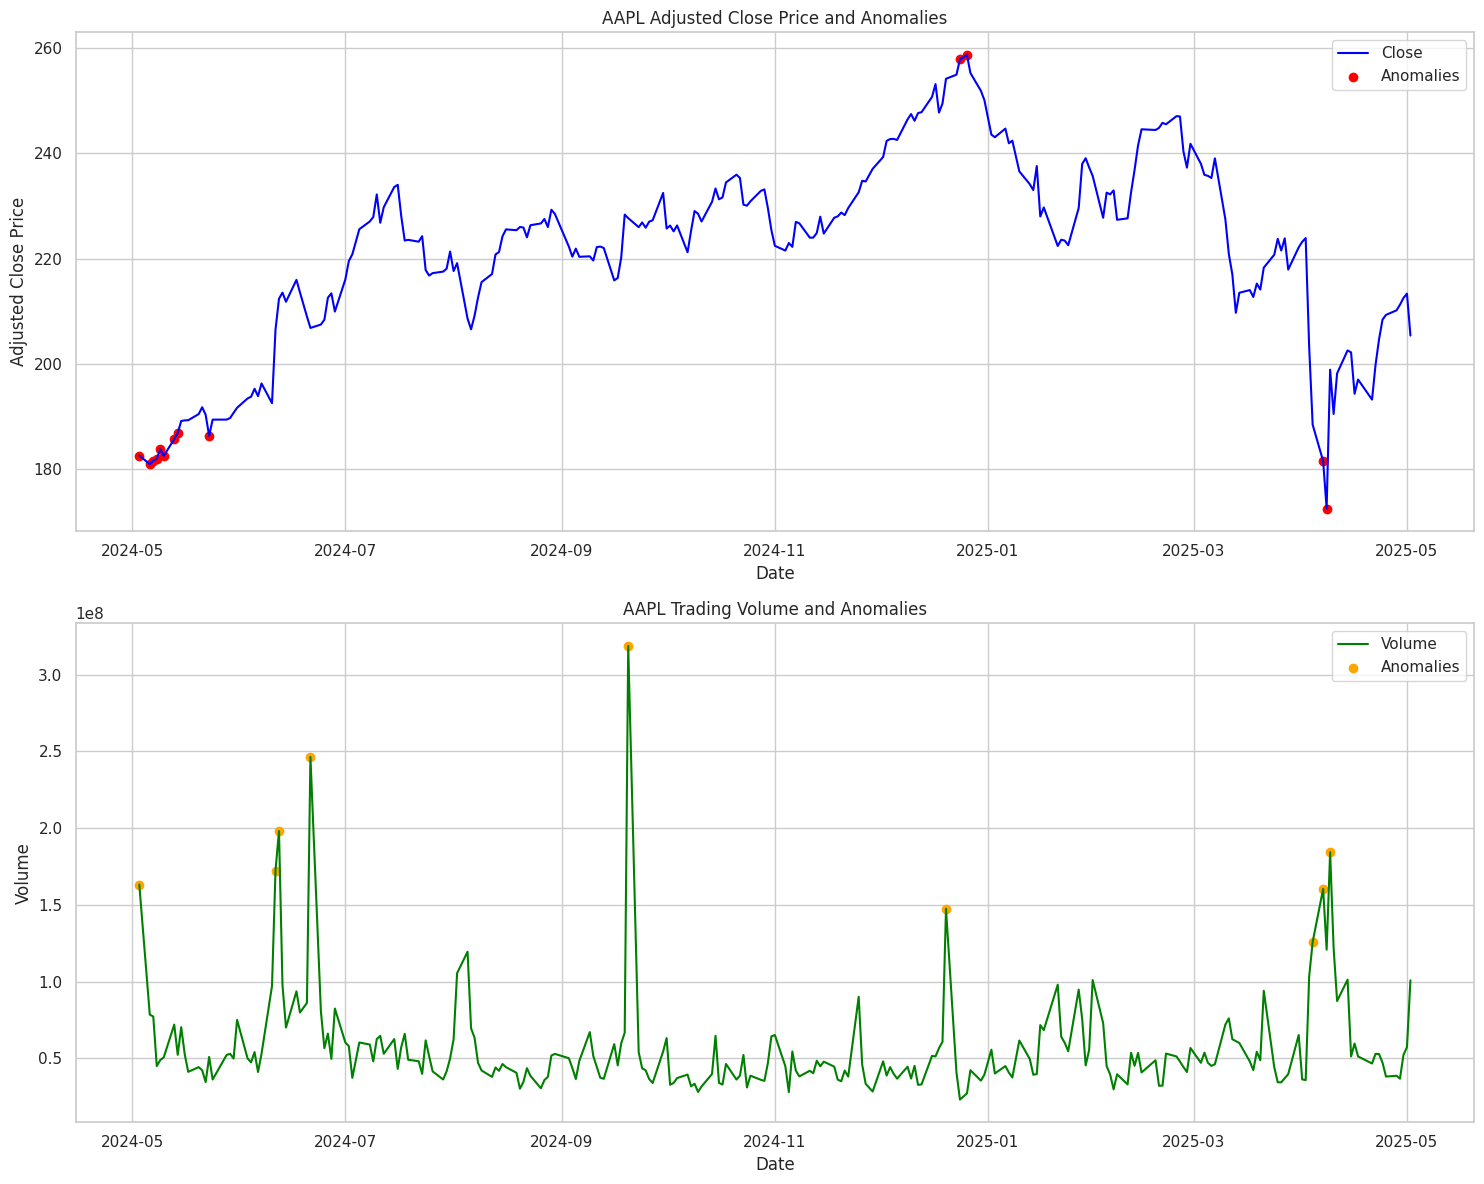

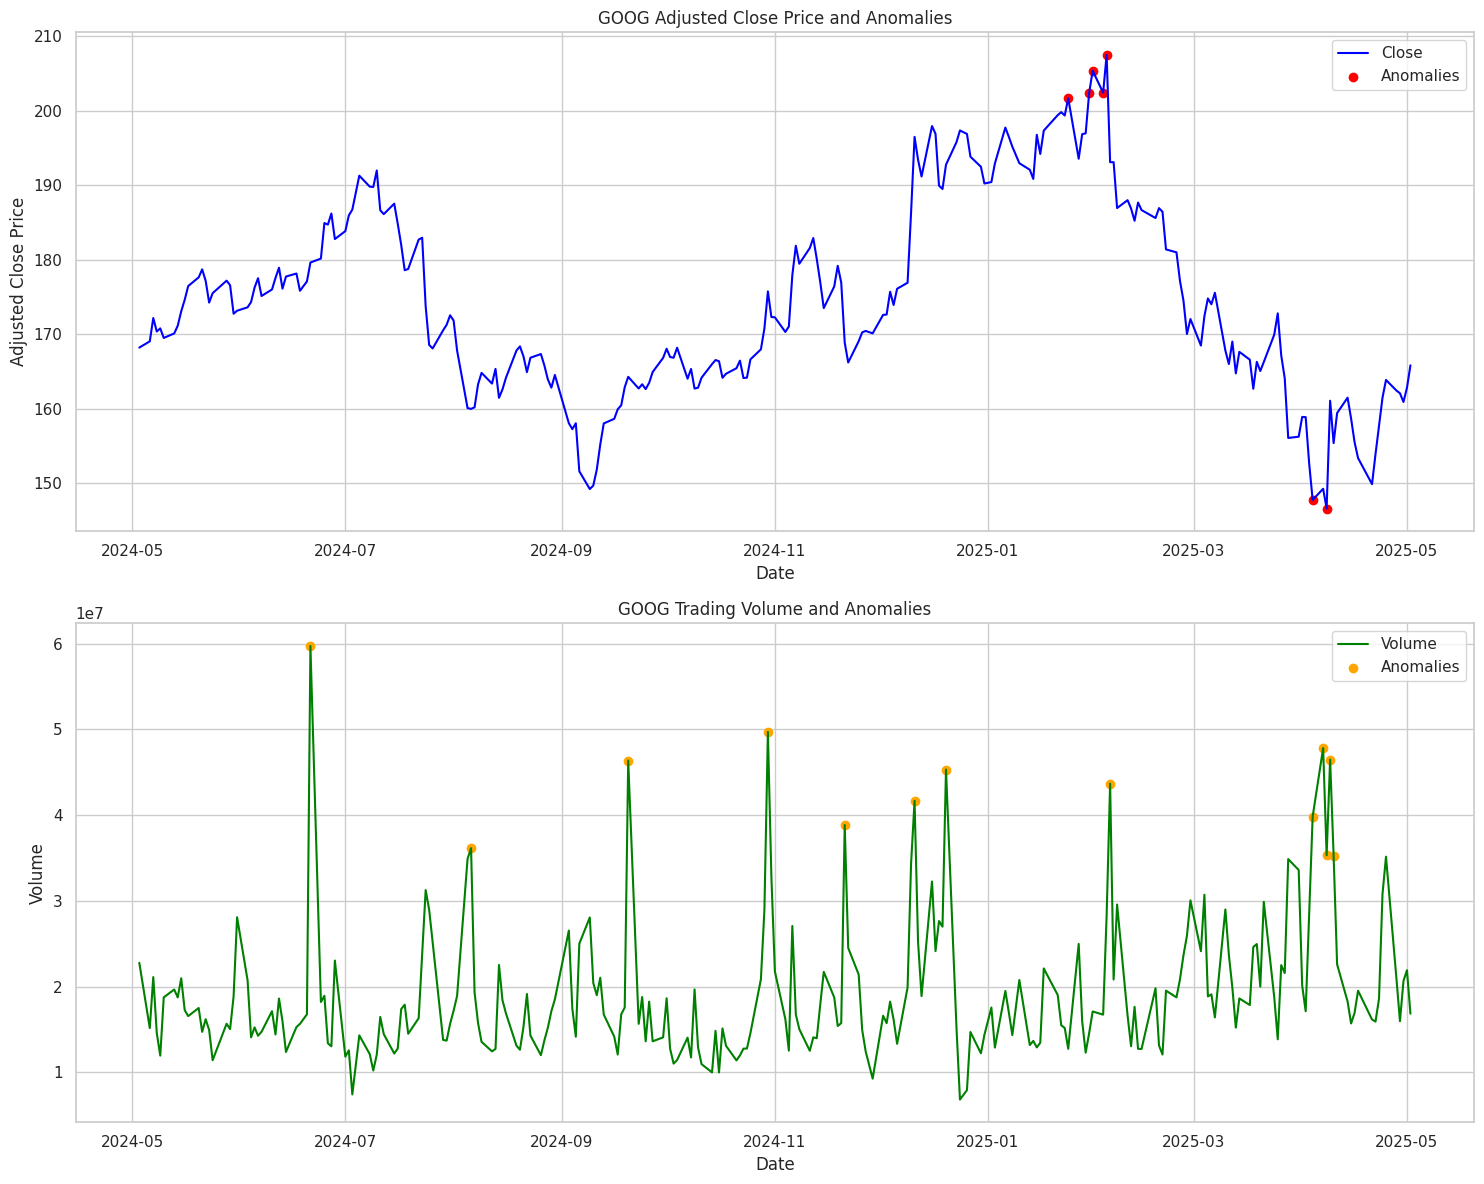

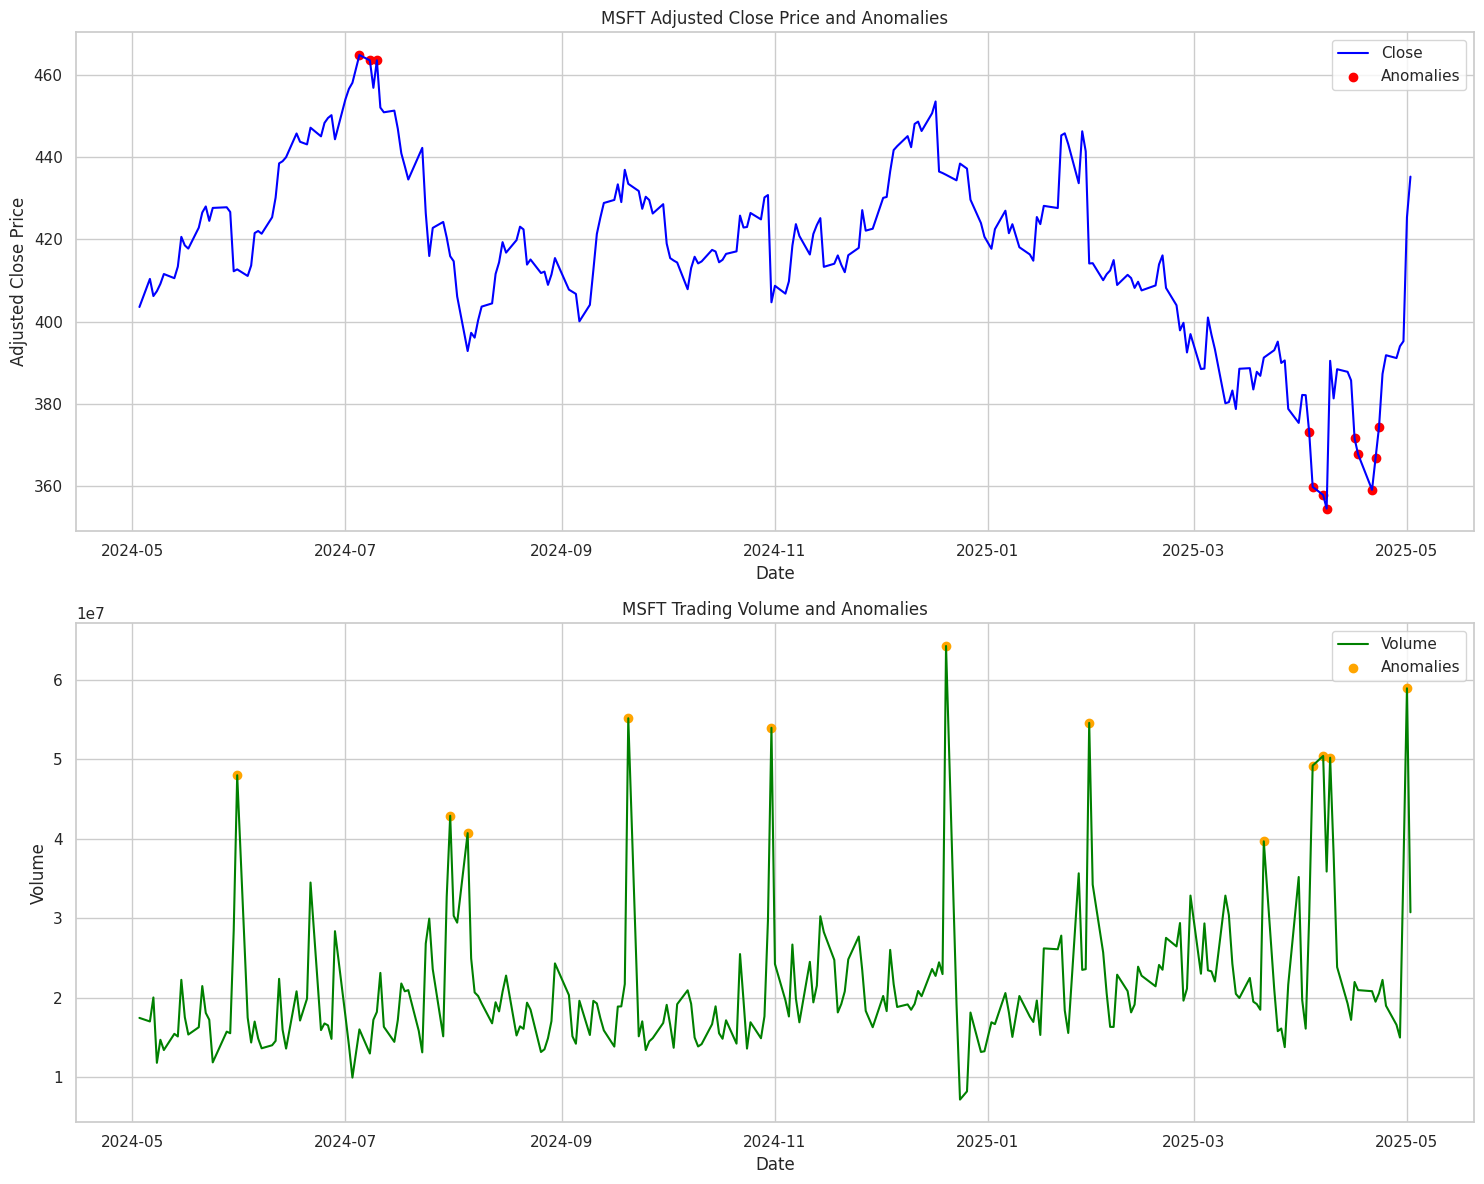

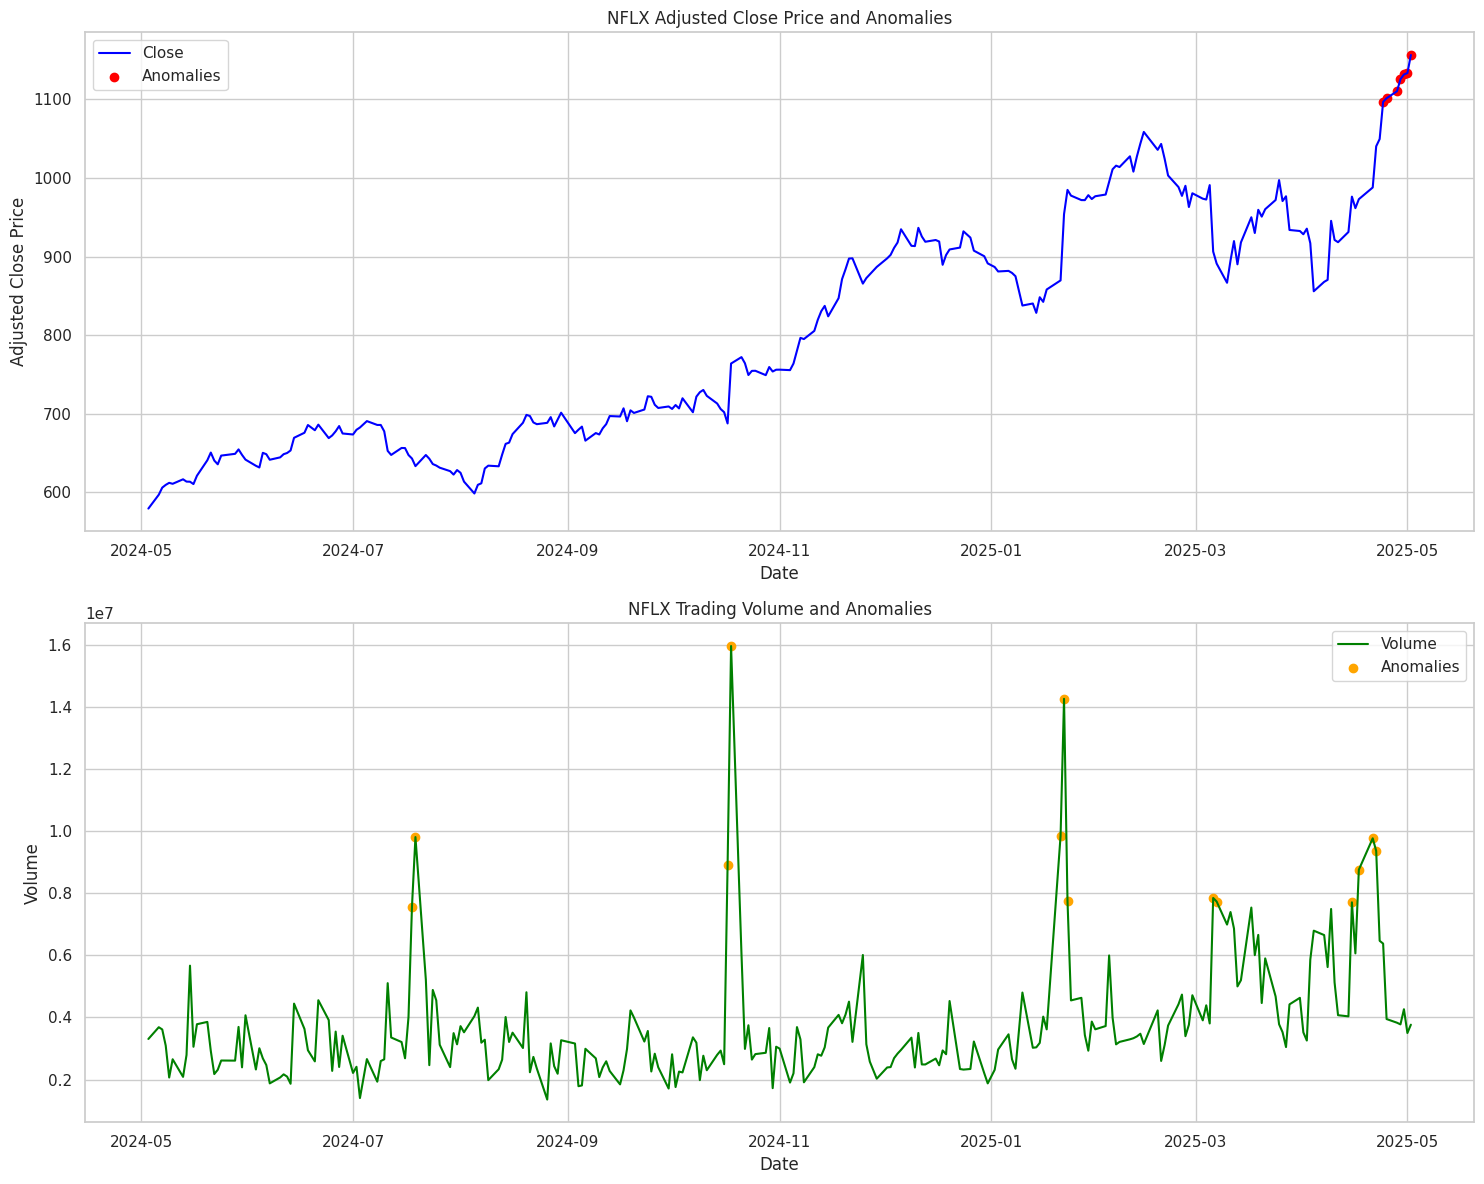

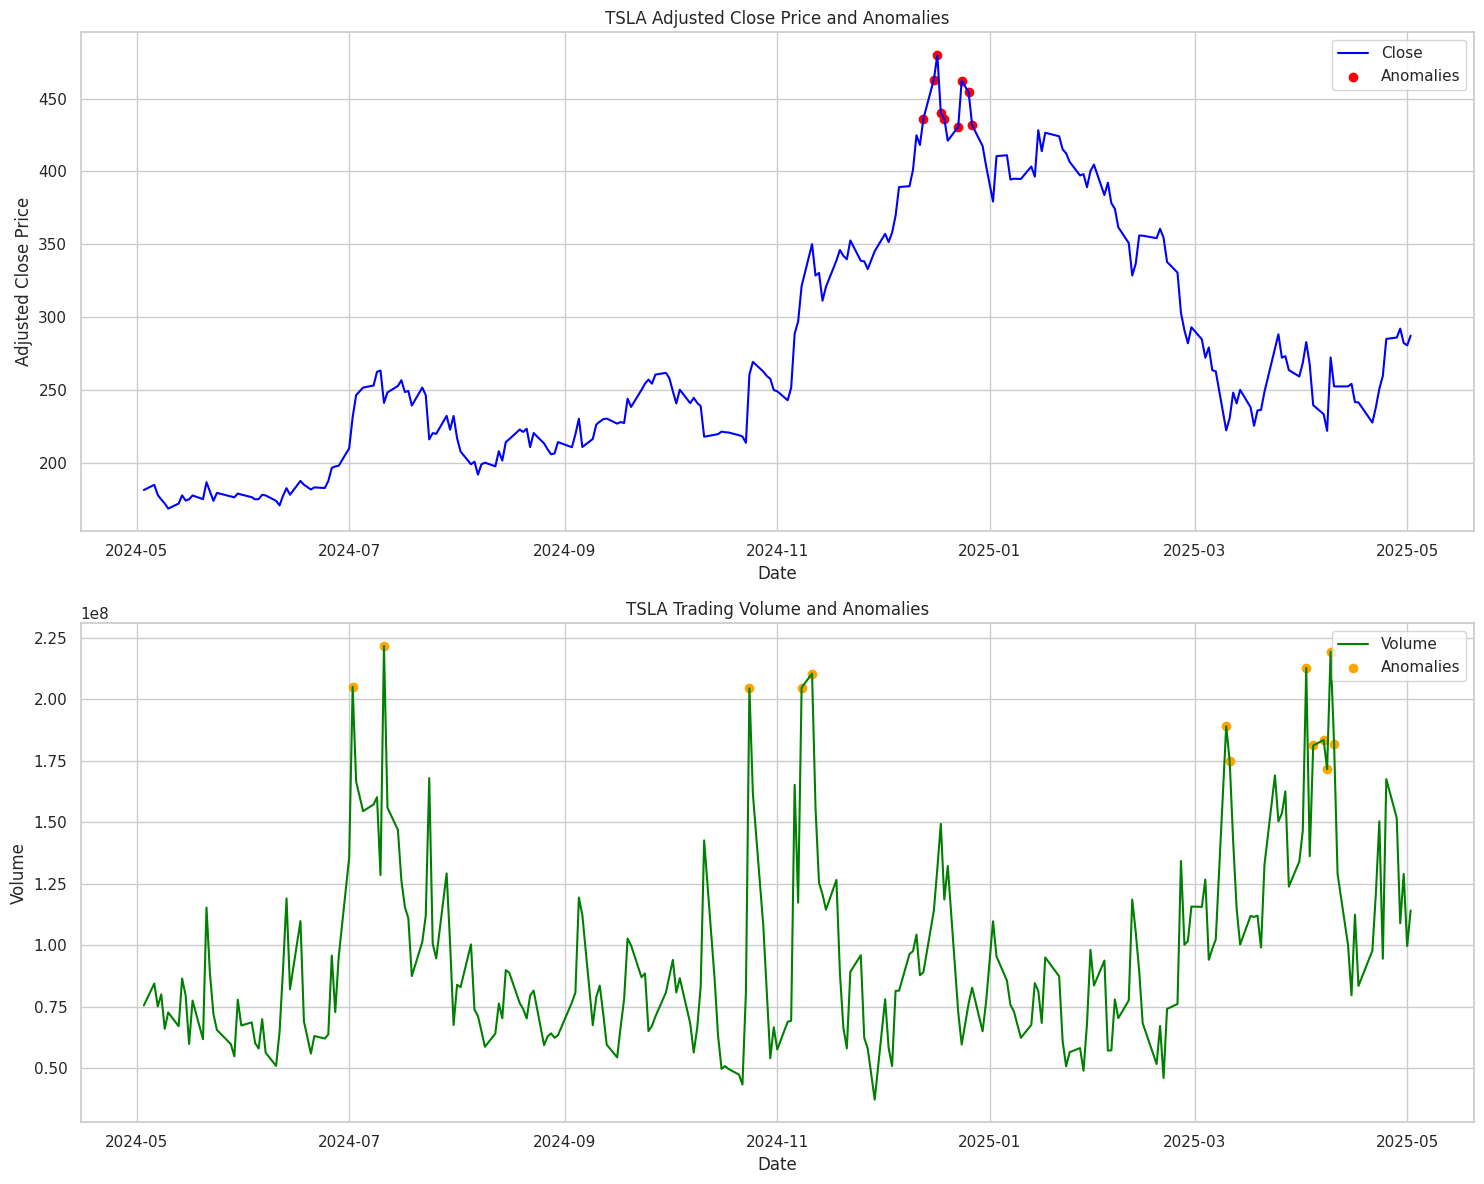

In [11]:
def plot_anomalies(ticker, anomalies_adj_close, anomalies_volume):

    data_ticker = stock_data[stock_data['Ticker'] == ticker]
    adj_close_anomalies = anomalies_adj_close[anomalies_adj_close['Ticker'] == ticker]
    volume_anomalies = anomalies_volume[anomalies_volume['Ticker'] == ticker]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

    ax1.plot(data_ticker.index, data_ticker['Close'], label='Close', color='blue')
    ax1.scatter(adj_close_anomalies.index, adj_close_anomalies['Close'], color='red', label='Anomalies')
    ax1.set_title(f'{ticker} Adjusted Close Price and Anomalies')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Adjusted Close Price')
    ax1.legend()


    ax2.plot(data_ticker.index, data_ticker['Volume'], label='Volume', color='green')
    ax2.scatter(volume_anomalies.index, volume_anomalies['Volume'], color='orange', label='Anomalies')
    ax2.set_title(f'{ticker} Trading Volume and Anomalies')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Volume')
    ax2.legend()

    plt.tight_layout()
    plt.show()
for ticker in stock_data['Ticker'].unique():
    plot_anomalies(ticker, anomalies_adj_close, anomalies_volume)

In [12]:

all_anomalies_adj_close = anomalies_adj_close[['Ticker']].copy()
all_anomalies_adj_close['Adj Close Anomaly'] = 1
all_anomalies_volume = anomalies_volume[['Ticker']].copy()
all_anomalies_volume['Volume Anomaly'] = 1
adj_close_pivot = all_anomalies_adj_close.pivot_table(index=all_anomalies_adj_close.index, columns='Ticker',
                                                       fill_value=0, aggfunc='sum')
volume_pivot = all_anomalies_volume.pivot_table(index=all_anomalies_volume.index, columns='Ticker',
                                                fill_value=0, aggfunc='sum')
adj_close_pivot.columns = adj_close_pivot.columns.get_level_values(1)
volume_pivot.columns = volume_pivot.columns.get_level_values(1)
combined_anomalies = pd.concat([adj_close_pivot, volume_pivot], axis=1, keys=['Adj Close Anomaly', 'Volume Anomaly'])
correlation_matrix = combined_anomalies.corr()

print(correlation_matrix)

                         Adj Close Anomaly                              \
Ticker                                AAPL          GOOG          MSFT   
                  Ticker                                                 
Adj Close Anomaly AAPL            1.000000 -1.612287e-01 -1.954387e-01   
                  GOOG           -0.161229  1.000000e+00 -1.962616e-17   
                  MSFT           -0.195439 -1.962616e-17  1.000000e+00   
                  NFLX           -0.299425 -2.000000e-01 -2.828427e-01   
                  TSLA           -0.098620 -2.335497e-01 -3.302891e-01   
Volume Anomaly    AAPL            0.500000  1.387779e-17  0.000000e+00   
                  GOOG            0.500000  5.000000e-01  5.000000e-01   
                  MSFT           -0.158114  3.162278e-01 -3.162278e-01   
                  NFLX           -0.500000 -5.000000e-01  5.000000e-01   
                  TSLA            0.500000  5.000000e-01  5.000000e-01   

                                     

In [13]:

adj_close_risk = anomalies_adj_close.groupby('Ticker')['Z-score'].apply(lambda x: abs(x).mean())
volume_risk = anomalies_volume.groupby('Ticker')['Z-score'].apply(lambda x: abs(x).mean())
total_risk = adj_close_risk + volume_risk
risk_rating = (total_risk - total_risk.min()) / (total_risk.max() - total_risk.min())

print(risk_rating)

Ticker
AAPL    1.000000
GOOG    0.269798
MSFT    0.666331
NFLX    0.278557
TSLA    0.000000
Name: Z-score, dtype: float64
